### PCA from full_v2.csv (feature exclusion by dropping of duplicate data from features)

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random as rd



In [68]:
df_pca = pd.read_csv('../dataset/pca_transformed_data_2026-09-19_15-44-54.csv')
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,Activity,subject
0,-5.537858,0.716345,1.412546,-1.733302,-0.920246,0.467883,STANDING,1
1,-5.564174,0.579506,1.827912,-0.796021,-0.626565,-0.991651,STANDING,1
2,-5.499319,0.297684,2.148152,-0.604225,-0.005493,0.026151,STANDING,1
3,-5.700396,-0.354586,2.149211,-0.328516,-0.791819,-0.898207,STANDING,1
4,-5.769082,-0.559389,2.365302,-0.333767,-0.448452,-0.328038,STANDING,1


In [69]:
X = df_pca.drop(["Activity", "subject"], axis=1) # Predictors (69 components)
y = df_pca["Activity"]                        # Target variable
le = LabelEncoder()
y = le.fit_transform(y)
y = pd.DataFrame(y)
groups = df_pca["subject"]

In [70]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=rd.randint(0,424289))

# Get indices for train and test sets based on Subject groups
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

train_subjects = sorted(groups_train.unique())
test_subjects = sorted(groups_test.unique())

print("Subjects in training data:")
print(train_subjects)

print("\nSubjects in test data:")
print(test_subjects)

print("\nNumber of training subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)
print("\nOverlapping subjects:", overlap)

Subjects in training data:
[np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(17), np.int64(18), np.int64(20), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Subjects in test data:
[np.int64(4), np.int64(5), np.int64(14), np.int64(15), np.int64(16), np.int64(19), np.int64(21), np.int64(22)]

Number of training subjects: 22
Number of test subjects: 8

Overlapping subjects: set()


In [71]:
# Find best hyperparameters using GridSearchCV (optional)
from sklearn.model_selection import GridSearchCV


param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.5, 0.7, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'reg_lambda': [0.1, 1.0, 10.0],
    'reg_alpha': [0, 0.1, 1.0]
}

model = xgb.XGBClassifier(random_state=42)

grid_search = RandomizedSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Initialize and train model
random_search_best_params = grid_search.best_params_
print("Best hyperparameters found by RandomizedSearchCV:")
print(random_search_best_params)

model = xgb.XGBClassifier(**random_search_best_params, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_decoded = le.inverse_transform(y_test)
y_pred_decoded = le.inverse_transform(y_pred)
y_decoded = pd.DataFrame(y_decoded)
y_pred_decoded = pd.DataFrame(y_pred_decoded)

print("--- Classification Report (Unseen Subjects) ---")
print(classification_report(y_decoded, y_pred_decoded))

Best hyperparameters found by RandomizedSearchCV:
{'subsample': 0.5, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.3, 'gamma': 0.1, 'colsample_bytree': 0.5}
--- Classification Report (Unseen Subjects) ---
                    precision    recall  f1-score   support

            LAYING       0.97      1.00      0.98       544
           SITTING       0.68      0.62      0.64       496
          STANDING       0.69      0.72      0.70       528
           WALKING       0.99      0.66      0.79       430
WALKING_DOWNSTAIRS       0.60      0.91      0.72       346
  WALKING_UPSTAIRS       0.75      0.67      0.71       381

          accuracy                           0.77      2725
         macro avg       0.78      0.76      0.76      2725
      weighted avg       0.79      0.77      0.77      2725



/Users/jonaskarlsen/Documents/git/haml-et/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:161: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


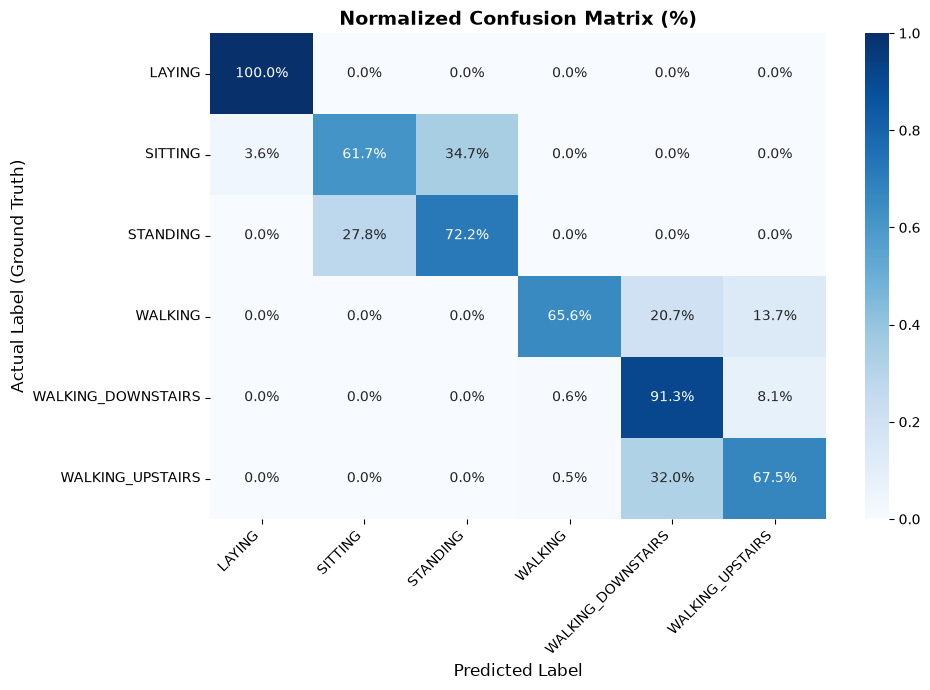

In [72]:
# Compute normalized matrix (percentages along rows)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# Get activity labels in the same order used by LabelEncoder
labels = le.classes_

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%',              # Format as percentage (e.g., 70.2%)
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()